<a href="https://colab.research.google.com/github/Karan-Potdukhe/AI-ML-DL-Hacktoberfest2024-WB/blob/Karan-Potdukhe-patch-1/Main_1_VAE_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape, Conv2D, Conv2DTranspose, Lambda
from tensorflow.keras.models import Model
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras import backend as K
from tensorflow.keras.optimizers import Adam
from PIL import Image
import matplotlib.pyplot as plt


In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import drive

In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

# Specify the folder path in your Google Drive
folder_path = '/content/drive/MyDrive/dataset/GAN/Celebrrity New Data'


In [ ]:
# Load images and preprocess them
def load_images(folder_path, img_size=(64, 64)):
    images = []
    for file_name in os.listdir(folder_path):
        if file_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(folder_path, file_name)
            img = Image.open(img_path).resize(img_size)
            img = np.array(img) / 255.0  # Normalize to [0, 1]
            images.append(img)
    return np.array(images)

images = load_images(folder_path)
print("Dataset shape:", images.shape)  # Should be (num_images, 64, 64, 3)

Dataset shape: (1006, 64, 64, 3)


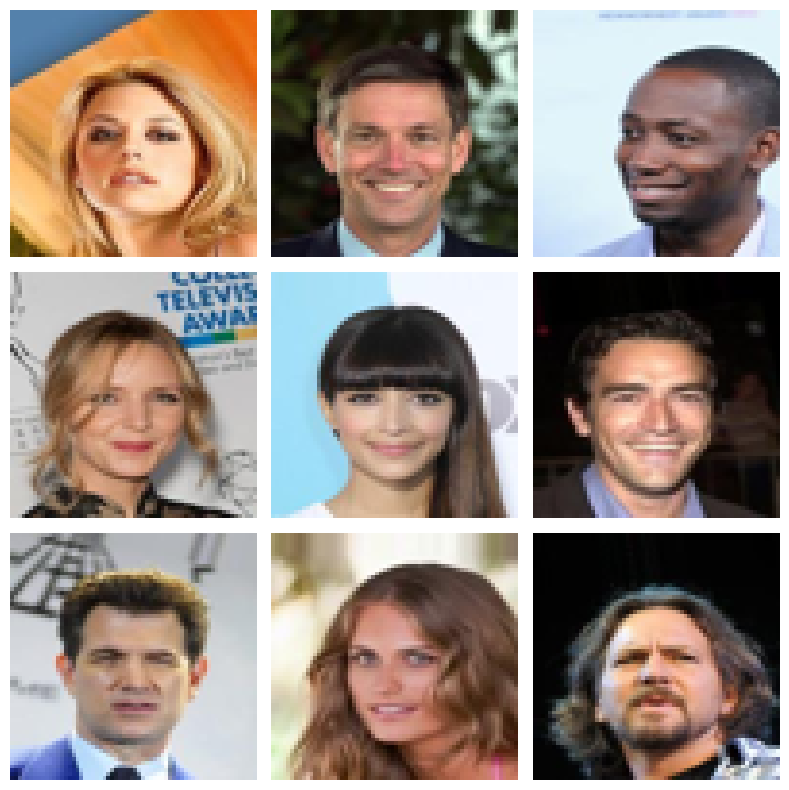

In [ ]:
# Visualize some images
def visualize_images(images, n=9):
    plt.figure(figsize=(8, 8))
    for i in range(n):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

visualize_images(images)

In [ ]:
latent_dim = 32  # Dimension of latent space

def build_encoder(input_shape, latent_dim):
    inputs = Input(shape=input_shape)
    x = Conv2D(32, (3, 3), activation='relu', strides=2, padding='same')(inputs)
    x = Conv2D(64, (3, 3), activation='relu', strides=2, padding='same')(x)
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)

    # Latent space
    z_mean = Dense(latent_dim, name="z_mean")(x)
    z_log_var = Dense(latent_dim, name="z_log_var")(x)

    # Sampling function
    def sampling(args):
        z_mean, z_log_var = args
        epsilon = K.random_normal(shape=(K.shape(z_mean)[0], latent_dim))
        return z_mean + K.exp(0.5 * z_log_var) * epsilon

    z = Lambda(sampling, output_shape=(latent_dim,), name="z")([z_mean, z_log_var])
    return Model(inputs, [z_mean, z_log_var, z], name="encoder")

encoder = build_encoder((64, 64, 3), latent_dim)
encoder.summary()


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 64, 64, 3)      │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 32, 32, 32)     │            896 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 16, 16, 64)     │         18,496 │ conv2d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten (Flatten)         │ (None, 16384)          │              0 │ conv2d_1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 128)            │      2,097,280 │ flatten[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ z_mean (Dense)            │ (None, 32)             │          4,128 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ z_log_var (Dense)         │ (None, 32)             │          4,128 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ z (Lambda)                │ (None, 32)             │              0 │ z_mean[0][0],          │
│                           │                        │                │ z_log_var[0][0]        │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 2,124,928 (8.11 MB)

 Trainable params: 2,124,928 (8.11 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def build_decoder(latent_dim, output_shape):
    latent_inputs = Input(shape=(latent_dim,))
    x = Dense(16 * 16 * 64, activation='relu')(latent_inputs)
    x = Reshape((16, 16, 64))(x)
    x = Conv2DTranspose(64, (3, 3), activation='relu', strides=2, padding='same')(x)
    x = Conv2DTranspose(32, (3, 3), activation='relu', strides=2, padding='same')(x)
    outputs = Conv2DTranspose(3, (3, 3), activation='sigmoid', padding='same')(x)
    return Model(latent_inputs, outputs, name="decoder")

decoder = build_decoder(latent_dim, (64, 64, 3))
decoder.summary()


Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16384)               │         540,672 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose (Conv2DTranspose)   │ (None, 32, 32, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_1 (Conv2DTranspose) │ (None, 64, 64, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_2 (Conv2DTranspose) │ (None, 64, 64, 3)           │             867 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 596,931 (2.28 MB)

 Trainable params: 596,931 (2.28 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
class VAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstructed = self.decoder(z)

        # KL divergence loss
        kl_loss = -0.5 * K.sum(1 + z_log_var - K.square(z_mean) - K.exp(z_log_var), axis=-1)
        self.add_loss(K.mean(kl_loss))

        return reconstructed

vae = VAE(encoder, decoder)
vae.compile(optimizer=Adam(), loss=MeanSquaredError())


In [ ]:
vae.fit(images, images, epochs=20, batch_size=32)


Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 322ms/step - loss: 0.3596
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 299ms/step - loss: 0.0857
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 303ms/step - loss: 0.0849
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 347ms/step - loss: 0.0843
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 271ms/step - loss: 0.0847
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 337ms/step - loss: 0.0815
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 311ms/step - loss: 0.0821
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 309ms/step - loss: 0.0807
Epoch 9/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 353ms/step - loss: 0.0810
Epoch 10/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 320ms/step - loss: 0.0800
Epoch 11/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 305ms/step - loss: 0.0828
Epoch 12/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 353ms/step - loss: 0.0796
Epoch 13/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 376ms/step - loss: 0.0807
Epoch 14/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 346ms/step - loss: 0.0806
Epoch 15/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 2

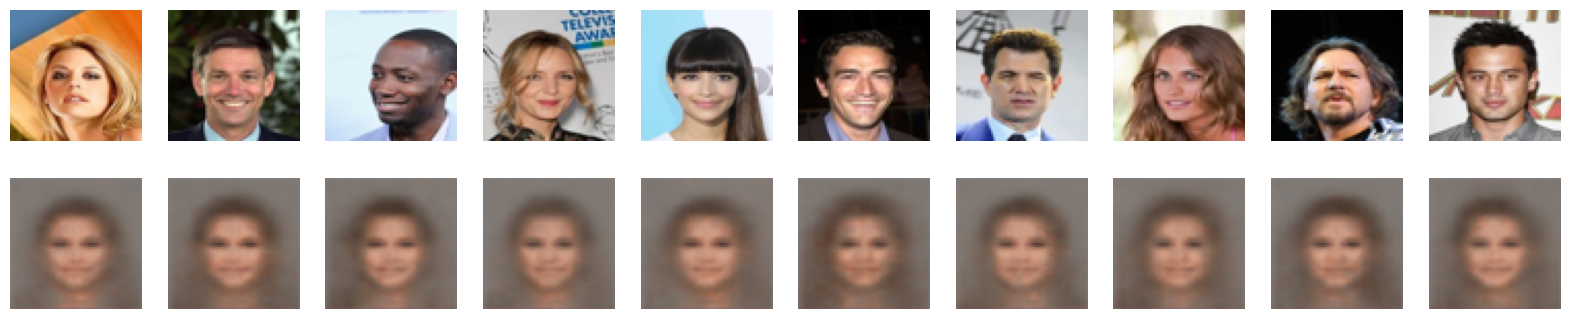

In [ ]:
def visualize_reconstructions(model, images):
    n = 10  # Number of images to display
    plt.figure(figsize=(20, 4))
    for i in range(n):
        # Original images
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(images[i])
        plt.axis("off")

        # Reconstructed images
        reconstructed = model(images[i:i+1]).numpy()
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructed[0])
        plt.axis("off")
    plt.show()

visualize_reconstructions(vae, images)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


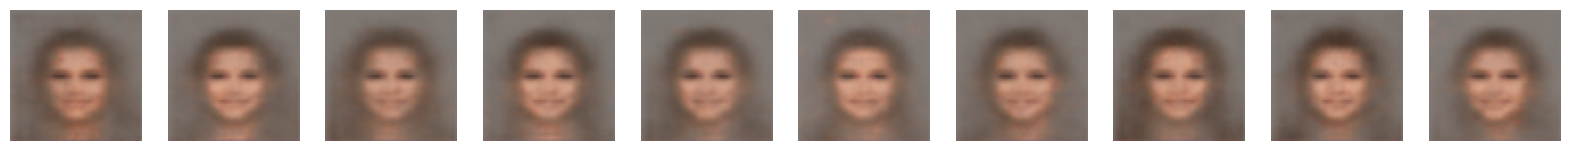

In [ ]:
def generate_new_images(decoder, latent_dim, n=10):
    random_latent_vectors = np.random.normal(size=(n, latent_dim))
    generated_images = decoder.predict(random_latent_vectors)

    plt.figure(figsize=(20, 4))
    for i in range(n):
        ax = plt.subplot(1, n, i + 1)
        plt.imshow(generated_images[i])
        plt.axis("off")
    plt.show()

generate_new_images(decoder, latent_dim)
